# 05 – Modelagem Preditiva (Machine Learning)
**Objetivo:** Treinar, otimizar e avaliar modelos de classificação para prever o desfecho de óbito hospitalar (indicador_obito) em pacientes internados por IAM. Faremos a comparação entre modelos lineares e baseados em árvores, seguidos de análise de interpretabilidade.

In [ ]:
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device configurado para processamento: {DEVICE}")


In [2]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Preprocessing & Metrics
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Interpretability
import shap

import warnings
warnings.filterwarnings('ignore')

FIG_PATH = Path('../reports/figures')
FIG_PATH.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid')

/home/carolina/miniconda3/envs/iam/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Carregamento e Pré-processamento
Carregaremos a base reduzida (saída do notebook 03). Faremos o tratamento de variáveis categóricas (One-Hot Encoding) e a divisão em Treino/Teste.

In [3]:
DATA_PATH = Path('../data/processed/base_modelagem_reduzida.csv')
df = pd.read_csv(DATA_PATH, low_memory=False)

# Garantir tipo do target
df['indicador_obito'] = df['indicador_obito'].astype(int)

# Separar X e y
X = df.drop(columns=['indicador_obito'])
y = df['indicador_obito']

# One-Hot Encoding para categóricas
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# XGBoost e LightGBM não gostam de caracteres especiais nas colunas (como <, > ou [, ])
X_encoded.columns = [re.sub(r'[\[\]<>\s]', '_', col) for col in X_encoded.columns]

# Split 80/20 estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Treino: {X_train.shape}")
print(f"Teste:  {X_test.shape}")

Treino: (304472, 158)
Teste:  (76119, 158)


## 2. Tratamento de Desbalanceamento & Baseline
A classe de óbitos é minoritária. Os algoritmos baseados em árvore (XGBoost/LightGBM) possuem parâmetros como `scale_pos_weight` ou `is_unbalance` para lidar com isso nativamente. Para o baseline (Regressão Logística), usaremos `class_weight='balanced'`.

In [4]:
# O Baseline (Logistic Regression) não aceita valores nulos, então vamos imputar a mediana.
# Modelos baseados em árvore (XGBoost/LightGBM) lidam com nulos nativamente.

baseline_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

baseline_pipeline.fit(X_train, y_train)

y_pred_lr = baseline_pipeline.predict(X_test)
y_prob_lr = baseline_pipeline.predict_proba(X_test)[:, 1]

print("=== Logistic Regression (Baseline) ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")
print(classification_report(y_test, y_pred_lr))

# Para plotar a curva ROC depois, guardaremos a referência do modelo treinado
lr_model = baseline_pipeline

=== Logistic Regression (Baseline) ===
ROC-AUC: 0.9587
              precision    recall  f1-score   support

           0       0.99      0.84      0.91     68937
           1       0.39      0.95      0.55      7182

    accuracy                           0.85     76119
   macro avg       0.69      0.90      0.73     76119
weighted avg       0.94      0.85      0.88     76119



## 3. Modelos Avançados (Tree-based)
Treinamento de XGBoost e LightGBM, que geralmente perforam melhor em dados tabulares sem necessidade de scaling rigoroso.

In [5]:
# Cálculo do peso para lidar com classes desbalanceadas (Altas / Óbitos)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Peso aplicado à classe minoritária: {scale_pos_weight:.2f}\n")

# --- XGBoost ---
xgb_model = XGBClassifier(
    device='cuda',
    tree_method='hist',
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='auc',
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb))

# --- LightGBM (parâmetros ajustados para evitar aviso de convergência) ---
lgb_model = LGBMClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=20,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)
lgb_model.fit(X_train, y_train)

y_pred_lgb = lgb_model.predict(X_test)
y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]

print("=== LightGBM ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lgb):.4f}")
print(classification_report(y_test, y_pred_lgb))


Peso aplicado à classe minoritária: 9.60

=== XGBoost ===
ROC-AUC: 0.9498
              precision    recall  f1-score   support

           0       0.99      0.88      0.93     68937
           1       0.43      0.88      0.57      7182

    accuracy                           0.88     76119
   macro avg       0.71      0.88      0.75     76119
weighted avg       0.93      0.88      0.89     76119

=== LightGBM ===
ROC-AUC: 0.9507
              precision    recall  f1-score   support

           0       0.99      0.88      0.93     68937
           1       0.42      0.88      0.57      7182

    accuracy                           0.88     76119
   macro avg       0.71      0.88      0.75     76119
weighted avg       0.93      0.88      0.89     76119



## 3.1 Random Forest

O Random Forest é um ensemble de árvores de decisão treinadas com bootstrap e seleção aleatória de features. Comparado ao XGBoost e LightGBM, oferece maior interpretabilidade nativa via feature importances e é menos sensível a hiperparâmetros. Utilizamos `class_weight='balanced'` para compensar o desbalanceamento sem alterar a distribuição do treino.

> **Nota:** O Random Forest não suporta valores `NaN` nativamente — a imputação de mediana é aplicada antes do fit via `SimpleImputer`.

In [6]:
from sklearn.ensemble import RandomForestClassifier

# --- Random Forest ---
# RF não aceita NaN nativamente — imputamos a mediana antes do fit
imputer_rf = SimpleImputer(strategy='median')
X_train_rf = imputer_rf.fit_transform(X_train)
X_test_rf  = imputer_rf.transform(X_test)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
)
rf_model.fit(X_train_rf, y_train)

y_pred_rf = rf_model.predict(X_test_rf)
y_prob_rf = rf_model.predict_proba(X_test_rf)[:, 1]

print('=== Random Forest ===')
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}')
print(classification_report(y_test, y_pred_rf))


=== Random Forest ===
ROC-AUC: 0.8898
              precision    recall  f1-score   support

           0       0.97      0.83      0.89     68937
           1       0.32      0.79      0.46      7182

    accuracy                           0.82     76119
   macro avg       0.65      0.81      0.68     76119
weighted avg       0.91      0.82      0.85     76119



## 3.2 Validação Cruzada Estratificada (5-Fold)

Avaliamos a estabilidade do ROC-AUC de cada modelo com validação cruzada estratificada de 5 folds. A **média ± desvio-padrão** permite identificar overfitting e variância alta entre folds. Usamos `X_encoded` completo (treino + teste) para uma estimativa mais confiável.

In [7]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline as SKPipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Pipeline RF com imputação embutida (necessário para cross_val_score)
rf_pipeline = SKPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('rf', RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_leaf=5,
        class_weight='balanced', n_jobs=-1, random_state=42
    ))
])

print('Executando validação cruzada 5-fold (pode levar alguns minutos)...')
resultados_cv = {}
for nome, modelo in [
    ('Logistic Regression', baseline_pipeline),
    ('Random Forest',       rf_pipeline),
    ('XGBoost',             xgb_model),
    ('LightGBM',            lgb_model),
]:
    scores = cross_val_score(modelo, X_encoded, y, cv=cv,
                             scoring='roc_auc', n_jobs=-1)
    resultados_cv[nome] = scores
    print(f'{nome:<25}  AUC = {scores.mean():.4f} ± {scores.std():.4f}'
          f'  [{scores.min():.4f} – {scores.max():.4f}]')

print('\nValidação cruzada concluída.')


Executando validação cruzada 5-fold (pode levar alguns minutos)...
Logistic Regression        AUC = 0.9593 ± 0.0005  [0.9584 – 0.9599]
Random Forest              AUC = 0.8878 ± 0.0021  [0.8848 – 0.8910]
XGBoost                    AUC = 0.9495 ± 0.0013  [0.9470 – 0.9509]
LightGBM                   AUC = 0.9504 ± 0.0010  [0.9491 – 0.9518]

Validação cruzada concluída.


## 4. Avaliação e Comparação de Modelos
Plotar a Curva ROC comparando os modelos e visualizar as matrizes de confusão.

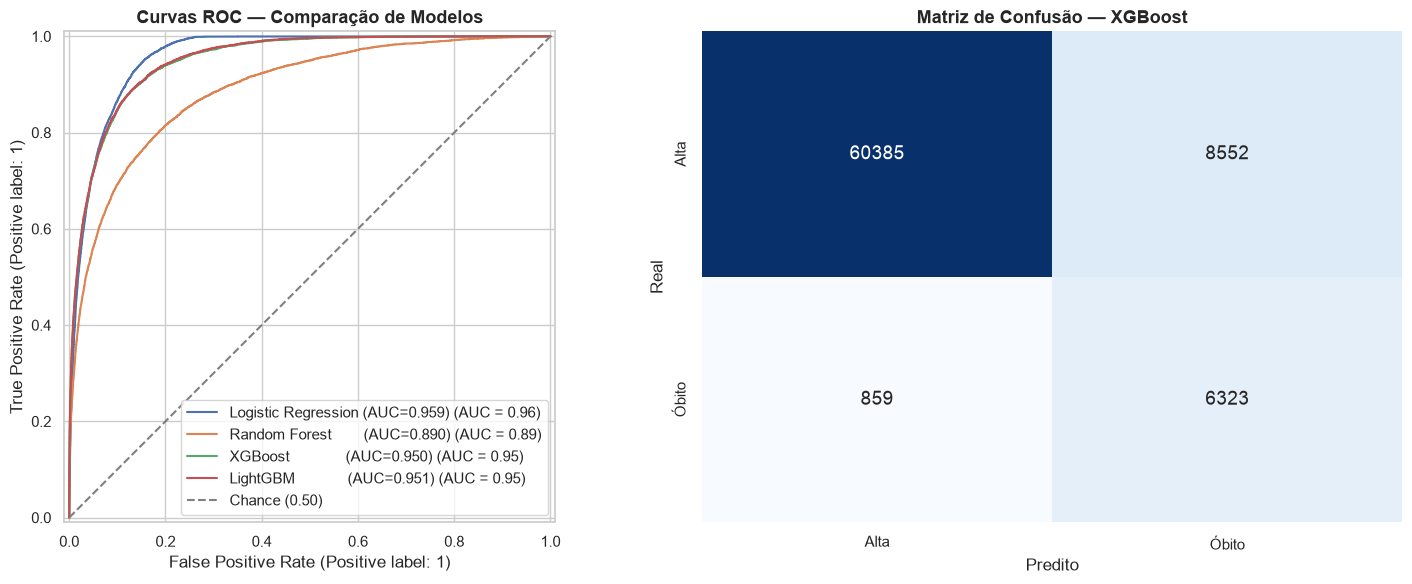

Figura salva em reports/figures/roc_confusion_matrix.png

=== RESUMO COMPARATIVO ===
Modelo                       ROC-AUC   Recall  Precision     F1
-----------------------------------------------------------------
Logistic Regression           0.9587   95.21%     38.71%  0.550
Random Forest                 0.8898   78.91%     32.08%  0.456
XGBoost                       0.9498   88.04%     42.51%  0.573
LightGBM                      0.9507   88.15%     42.42%  0.573


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Curvas ROC comparativas
RocCurveDisplay.from_estimator(lr_model,  X_test,    y_test, name=f'Logistic Regression (AUC={roc_auc_score(y_test, y_prob_lr):.3f})',  ax=axes[0])
RocCurveDisplay.from_estimator(rf_model,  X_test_rf, y_test, name=f'Random Forest        (AUC={roc_auc_score(y_test, y_prob_rf):.3f})', ax=axes[0])
RocCurveDisplay.from_estimator(xgb_model, X_test,    y_test, name=f'XGBoost              (AUC={roc_auc_score(y_test, y_prob_xgb):.3f})', ax=axes[0])
RocCurveDisplay.from_estimator(lgb_model, X_test,    y_test, name=f'LightGBM             (AUC={roc_auc_score(y_test, y_prob_lgb):.3f})', ax=axes[0])
axes[0].set_title('Curvas ROC — Comparação de Modelos', fontsize=13, fontweight='bold')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance (0.50)')
axes[0].legend(loc='lower right')

# Matriz de Confusão — XGBoost (melhor modelo tree-based por recall)
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False,
            annot_kws={'size': 14})
axes[1].set_title('Matriz de Confusão — XGBoost', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')
axes[1].set_xticklabels(['Alta', 'Óbito'])
axes[1].set_yticklabels(['Alta', 'Óbito'])

plt.tight_layout()
plt.savefig(FIG_PATH / 'roc_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura salva em reports/figures/roc_confusion_matrix.png')

# Tabela resumo
from sklearn.metrics import recall_score, precision_score, f1_score
print('\n=== RESUMO COMPARATIVO ===')
print(f"{'Modelo':<25} {'ROC-AUC':>10} {'Recall':>8} {'Precision':>10} {'F1':>6}")
print('-' * 65)
for nome, y_pred, y_prob in [
    ('Logistic Regression', y_pred_lr,  y_prob_lr),
    ('Random Forest',       y_pred_rf,  y_prob_rf),
    ('XGBoost',             y_pred_xgb, y_prob_xgb),
    ('LightGBM',            y_pred_lgb, y_prob_lgb),
]:
    auc  = roc_auc_score(y_test, y_prob)
    rec  = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    print(f'{nome:<25} {auc:>10.4f} {rec:>8.2%} {prec:>10.2%} {f1:>6.3f}')


## 4.1 Teste de DeLong — Significância Estatística entre Modelos

O teste de DeLong (1988) compara duas curvas ROC e testa se a diferença entre as AUCs é estatisticamente significativa. Aplicamos o teste entre XGBoost e LightGBM — os dois modelos com AUC mais próximas — e entre Regressão Logística e XGBoost.

In [9]:
from scipy import stats
import numpy as np

def delong_roc_test(y_true, y_prob_a, y_prob_b):
    n1 = y_true.sum()
    n0 = len(y_true) - n1
    order = np.argsort(-y_prob_a)
    psi_a = np.where(y_true[order] == 1,
                     np.cumsum(y_true[order] == 0) / n0, 0).sum() / n1
    order = np.argsort(-y_prob_b)
    psi_b = np.where(y_true[order] == 1,
                     np.cumsum(y_true[order] == 0) / n0, 0).sum() / n1
    def kernel(Y, X):
        psi = np.array([
            np.mean(np.where(X > y, 1, np.where(X == y, 0.5, 0))) for y in Y
        ])
        return psi
    pos = y_prob_a[y_true == 1]; neg = y_prob_a[y_true == 0]
    V10_a = kernel(pos, neg); V01_a = kernel(neg, pos)
    pos = y_prob_b[y_true == 1]; neg = y_prob_b[y_true == 0]
    V10_b = kernel(pos, neg); V01_b = kernel(neg, pos)
    S10 = np.cov(V10_a, V10_b)
    S01 = np.cov(V01_a, V01_b)
    S = S10 / n1 + S01 / n0
    auc_a = roc_auc_score(y_true, y_prob_a)
    auc_b = roc_auc_score(y_true, y_prob_b)
    z = (auc_a - auc_b) / np.sqrt(S[0,0] + S[1,1] - 2*S[0,1])
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return auc_a, auc_b, z, p

y_true_np   = y_test.to_numpy()
pairs = [
    ('XGBoost vs LightGBM',            y_prob_xgb, y_prob_lgb),
    ('Logistic Regression vs XGBoost', y_prob_lr,  y_prob_xgb),
    ('Logistic Regression vs LightGBM',y_prob_lr,  y_prob_lgb),
    ('Logistic Regression vs Random Forest', y_prob_lr, y_prob_rf),
]

print('=== Teste de DeLong — Comparação de AUCs ===')
print(f'{"Par":<40} {"AUC A":>8} {"AUC B":>8} {"z":>8} {"p-valor":>12} {"Sig.":>6}')
print('-' * 88)
for label, pa, pb in pairs:
    auc_a, auc_b, z, p = delong_roc_test(y_true_np, pa, pb)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f'{label:<40} {auc_a:>8.4f} {auc_b:>8.4f} {z:>8.2f} {p:>12.4e} {sig:>6}')


=== Teste de DeLong — Comparação de AUCs ===
Par                                         AUC A    AUC B        z      p-valor   Sig.
----------------------------------------------------------------------------------------
XGBoost vs LightGBM                        0.9498   0.9507    -4.04   5.3061e-05    ***
Logistic Regression vs XGBoost             0.9587   0.9498     9.52   0.0000e+00    ***
Logistic Regression vs LightGBM            0.9587   0.9507     8.81   0.0000e+00    ***
Logistic Regression vs Random Forest       0.9587   0.8898    36.94   0.0000e+00    ***


## 5. Interpretabilidade (SHAP)
Extrair o SHAP summary plot do melhor modelo para entender quais features mais contribuem para o risco de óbito.

Calculando SHAP values (pode levar alguns segundos)...


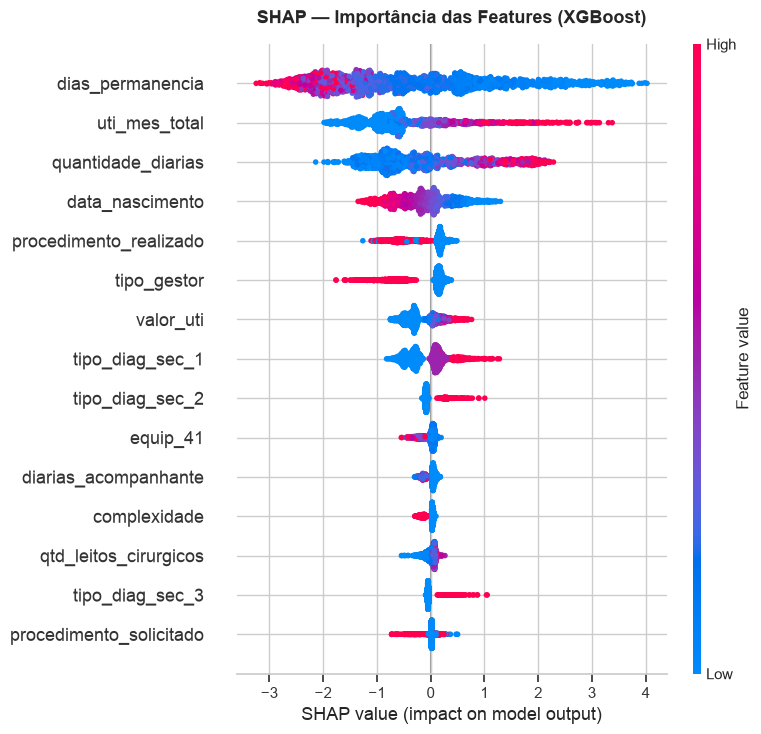

Figura salva em reports/figures/shap_summary_plot.png


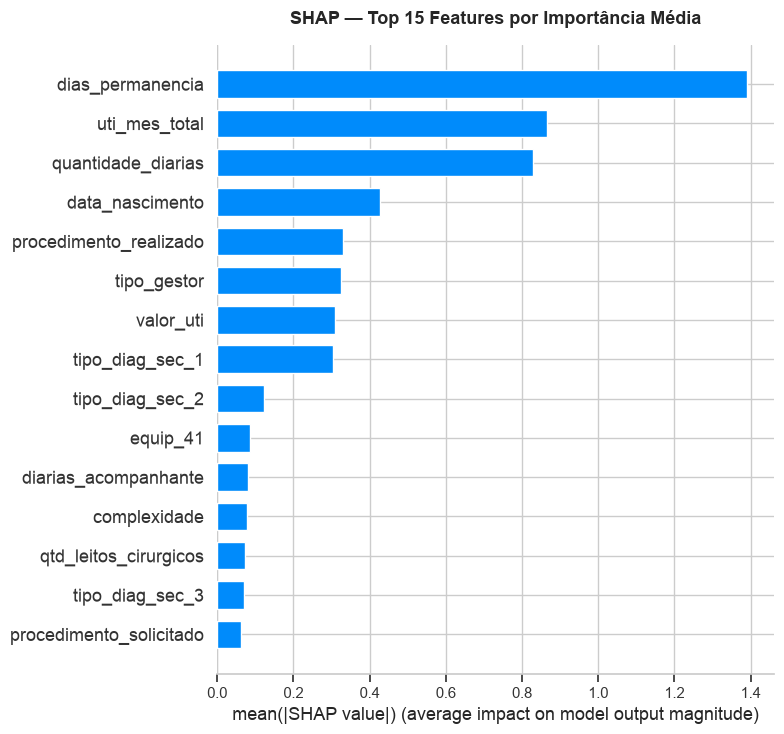

Figura salva em reports/figures/shap_bar_plot.png


In [10]:
# O SHAP explica o impacto de cada variável na predição do XGBoost
print("Calculando SHAP values (pode levar alguns segundos)...")
explainer = shap.TreeExplainer(xgb_model)

# Amostra de 2000 registros para performance
X_shap = X_test.sample(2000, random_state=42)
shap_values = explainer.shap_values(X_shap)

# Summary Plot — importância global + direção do efeito
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, max_display=15, show=False)
plt.title('SHAP — Importância das Features (XGBoost)', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(FIG_PATH / 'shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salva em reports/figures/shap_summary_plot.png")

# Bar Plot — importância média absoluta
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap, plot_type='bar', max_display=15, show=False)
plt.title('SHAP — Top 15 Features por Importância Média', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(FIG_PATH / 'shap_bar_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura salva em reports/figures/shap_bar_plot.png")
